### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

#### Intuition 

All the required libraries have been imported

### Load Dataset

In [2]:
df = pd.read_csv("../dataset/Message_Intelligence_Dataset.csv")


In [3]:
df.head()

,message_id,message_text,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,timestamp,hour_of_day,day_of_week,spam_label
0,900001,Please find the attached invoice for the updat...,99,11,1,4,0,0,1,56.6,500.0,6.0,2025-11-24 02:00:00,2,0,0
1,900002,Let's catch up tomorrow regarding the timeline...,73,12,0,0,0,0,0,16.6,207.0,0.0,2025-12-17 21:00:00,21,2,0
2,900003,Can you send the report by end of day? next Mo...,67,13,0,0,0,0,1,25.7,418.0,6.0,2025-11-15 13:00:00,13,5,0
3,900004,Can you send the report by end of day? 10:30 A...,64,13,0,4,0,0,1,48.8,276.0,5.0,2025-12-17 23:00:00,23,2,0
4,900005,Could you review the document and share feedba...,84,14,0,0,0,0,1,33.0,683.0,7.0,2025-11-29 11:00:00,11,5,0


#### Intuition 

The dataset includes message details such as message length, word count, URLs, digits, special characters, sender information, and the target column **spam_label**, which is used to classify messages as spam or legitimate.

### Check Dataset Shape

In [4]:
df.shape

(5200, 16)

#### Intuition

The dataset contains **5,200 rows** and **16 columns**. This means we have 5,200 message records with 16 different features, including the target column **spam_label** used for classification.

### Check Dataset Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   message_id               5200 non-null   int64  
 1   message_text             5200 non-null   object 
 2   message_length           5200 non-null   int64  
 3   word_count               5200 non-null   int64  
 4   num_urls                 5200 non-null   int64  
 5   num_digits               5200 non-null   int64  
 6   num_special_chars        5200 non-null   int64  
 7   spam_keyword_score       5200 non-null   int64  
 8   legit_keyword_score      5200 non-null   int64  
 9   sender_activity_score    5094 non-null   float64
 10  sender_account_age_days  5087 non-null   float64
 11  messages_sent_last_24h   5038 non-null   float64
 12  timestamp                5200 non-null   object 
 13  hour_of_day              5200 non-null   int64  
 14  day_of_week             

#### Intuition

The dataset contains 16 columns with different data types such as integer, float, and object. All columns have 5,200 non-null values, which indicates that there are no missing values in the dataset. This means the dataset is complete and ready for further analysis.

## DATA PREPROCESSING 

### Check Missing Values

In [6]:
df.isnull().sum()

message_id                   0
message_text                 0
message_length               0
word_count                   0
num_urls                     0
num_digits                   0
num_special_chars            0
spam_keyword_score           0
legit_keyword_score          0
sender_activity_score      106
sender_account_age_days    113
messages_sent_last_24h     162
timestamp                    0
hour_of_day                  0
day_of_week                  0
spam_label                   0
dtype: int64

#### Intuition

The dataset contains missing values in sender_activity_score (106), sender_account_age_days (113), and messages_sent_last_24h (162). All the remaining columns have no missing values. These missing values should be handled before training the machine learning models.

### Handling Missing Values 

In [7]:
df = df.fillna(df.median(numeric_only=True))

In [8]:
df.isnull().sum()

message_id                 0
message_text               0
message_length             0
word_count                 0
num_urls                   0
num_digits                 0
num_special_chars          0
spam_keyword_score         0
legit_keyword_score        0
sender_activity_score      0
sender_account_age_days    0
messages_sent_last_24h     0
timestamp                  0
hour_of_day                0
day_of_week                0
spam_label                 0
dtype: int64

#### Intuition 

The missing values in the numerical columns have been replaced with their median values. After filling the missing values, all columns are complete and the dataset is ready for the next preprocessing step.

### Check Duplicate Values 

In [9]:
df.duplicated().sum()

np.int64(0)

#### Intuition 

There are no duplicate values present in the datasset.

### Check Data Types

In [10]:
df.dtypes

message_id                   int64
message_text                object
message_length               int64
word_count                   int64
num_urls                     int64
num_digits                   int64
num_special_chars            int64
spam_keyword_score           int64
legit_keyword_score          int64
sender_activity_score      float64
sender_account_age_days    float64
messages_sent_last_24h     float64
timestamp                   object
hour_of_day                  int64
day_of_week                  int64
spam_label                   int64
dtype: object

#### Intuition 

The dataset contains different data types such as integer, float, and object. Most features are numerical, while message_text and timestamp are stored as object data types.

### Statistical Summary

In [11]:
df.describe()

,message_id,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,hour_of_day,day_of_week,spam_label
count,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000
mean,902600.500000,75.035962,11.457308,0.206538,1.681346,0.243654,0.246346,0.817692,54.835577,296.200962,8.261346,11.523462,3.038846,0.187115
std,1501.255031,12.455377,1.609056,0.404860,2.415846,0.545363,0.676798,0.556687,17.516597,189.679808,5.503428,6.861518,2.062504,0.390042
min,900001.000000,32.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,901300.750000,67.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,43.300000,153.000000,5.000000,6.000000,1.000000,0.000000
50%,902600.500000,74.000000,11.000000,0.000000,0.000000,0.000000,0.000000,1.000000,54.800000,275.000000,7.000000,12.000000,3.000000,0.000000
75%,903900.250000,81.000000,13.000000,0.000000,4.000000,0.000000,0.000000,1.000000,66.300000,407.000000,9.000000,17.000000,5.000000,0.000000
max,905200.000000,122.000000,16.000000,1.000000,9.000000,2.000000,3.000000,2.000000,100.000000,1500.000000,38.000000,23.000000,6.000000,1.000000


#### Intuition

The summary statistics show the count, mean, standard deviation, minimum, maximum, and quartile values for the numerical columns. 

## EDA - Exploratory Data Analysis 

### Target Variable Distribution 

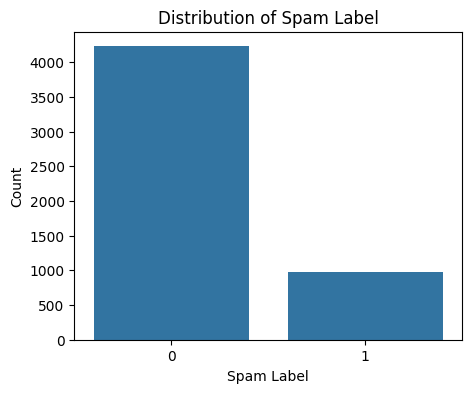

In [12]:
plt.figure(figsize=(5, 4))
sns.countplot(x="spam_label", data=df)

plt.title("Distribution of Spam Label")
plt.xlabel("Spam Label")
plt.ylabel("Count")

plt.show()

#### Intuition

The count plot shows that legitimate messages (0) are much higher than spam messages (1). This means the dataset is imbalanced, as one class contains significantly more records than the other. Since the dataset is imbalanced, we will compare the models using Accuracy, Precision, Recall and F1-Score.

### Histogram

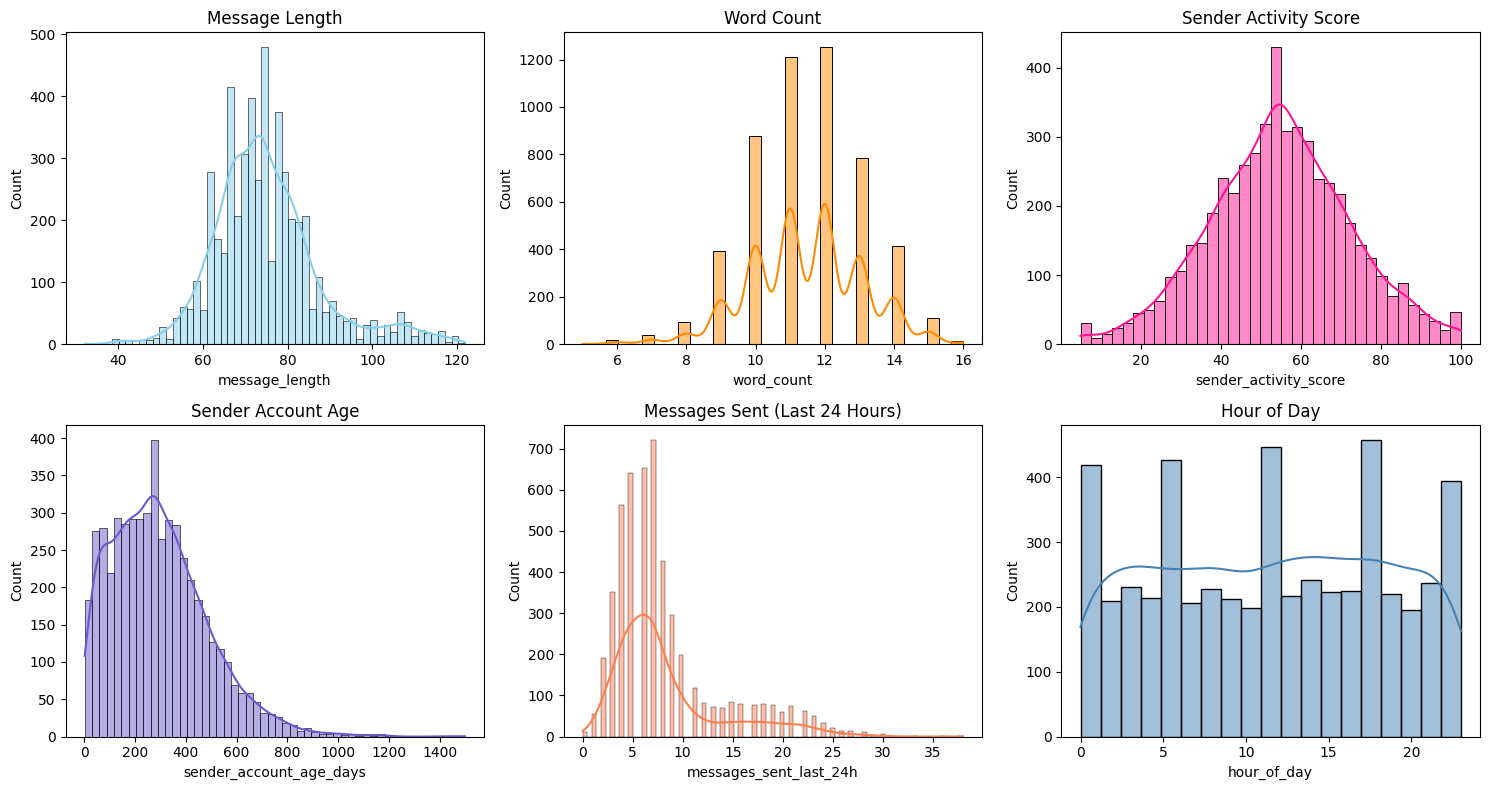

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

sns.histplot(df["message_length"], color="skyblue", edgecolor="black", kde=True, ax=axes[0,0])
axes[0,0].set_title("Message Length")

sns.histplot(df["word_count"], color="darkorange", edgecolor="black", kde=True, ax=axes[0,1])
axes[0,1].set_title("Word Count")

sns.histplot(df["sender_activity_score"], color="deeppink", edgecolor="black", kde=True, ax=axes[0,2])
axes[0,2].set_title("Sender Activity Score")

sns.histplot(df["sender_account_age_days"], color="slateblue", edgecolor="black", kde=True, ax=axes[1,0])
axes[1,0].set_title("Sender Account Age")

sns.histplot(df["messages_sent_last_24h"], color="coral", edgecolor="black", kde=True, ax=axes[1,1])
axes[1,1].set_title("Messages Sent (Last 24 Hours)")

sns.histplot(df["hour_of_day"], color="steelblue", edgecolor="black", kde=True, ax=axes[1,2])
axes[1,2].set_title("Hour of Day")

plt.tight_layout()
plt.show()

#### Intuition

The histograms show that different features have different distributions. Message Length and Sender Activity Score are close to a normal distribution, while Sender Account Age and Messages Sent (Last 24 Hours) are right-skewed. Hour of Day is spread across different hours.

### Correlation Heatmap

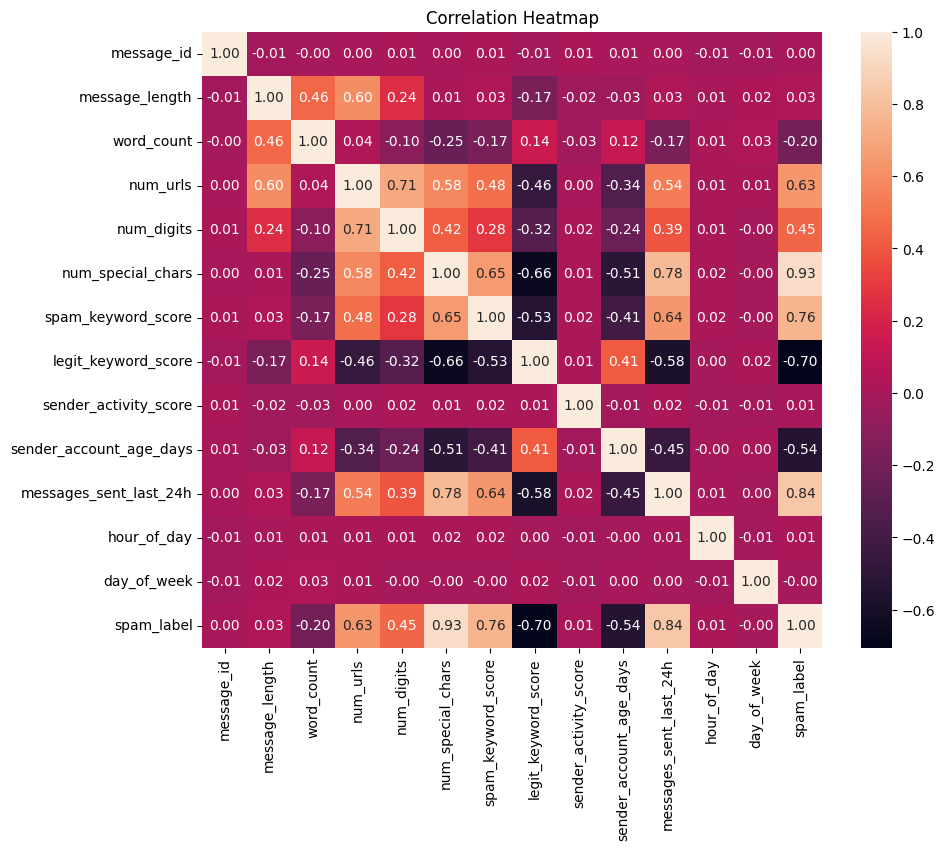

In [14]:
plt.figure(figsize=(10, 8))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="rocket", fmt=".2f")
plt.title("Correlation Heatmap")

plt.show()

#### Intuition

The heatmap shows that some features have a strong positive correlation, while others have a strong negative correlation. Features like spam_keyword_score and messages_sent_last_24h have a positive relationship with spam_label, whereas legit_keyword_score has a strong negative relationship. 


### Boxplots

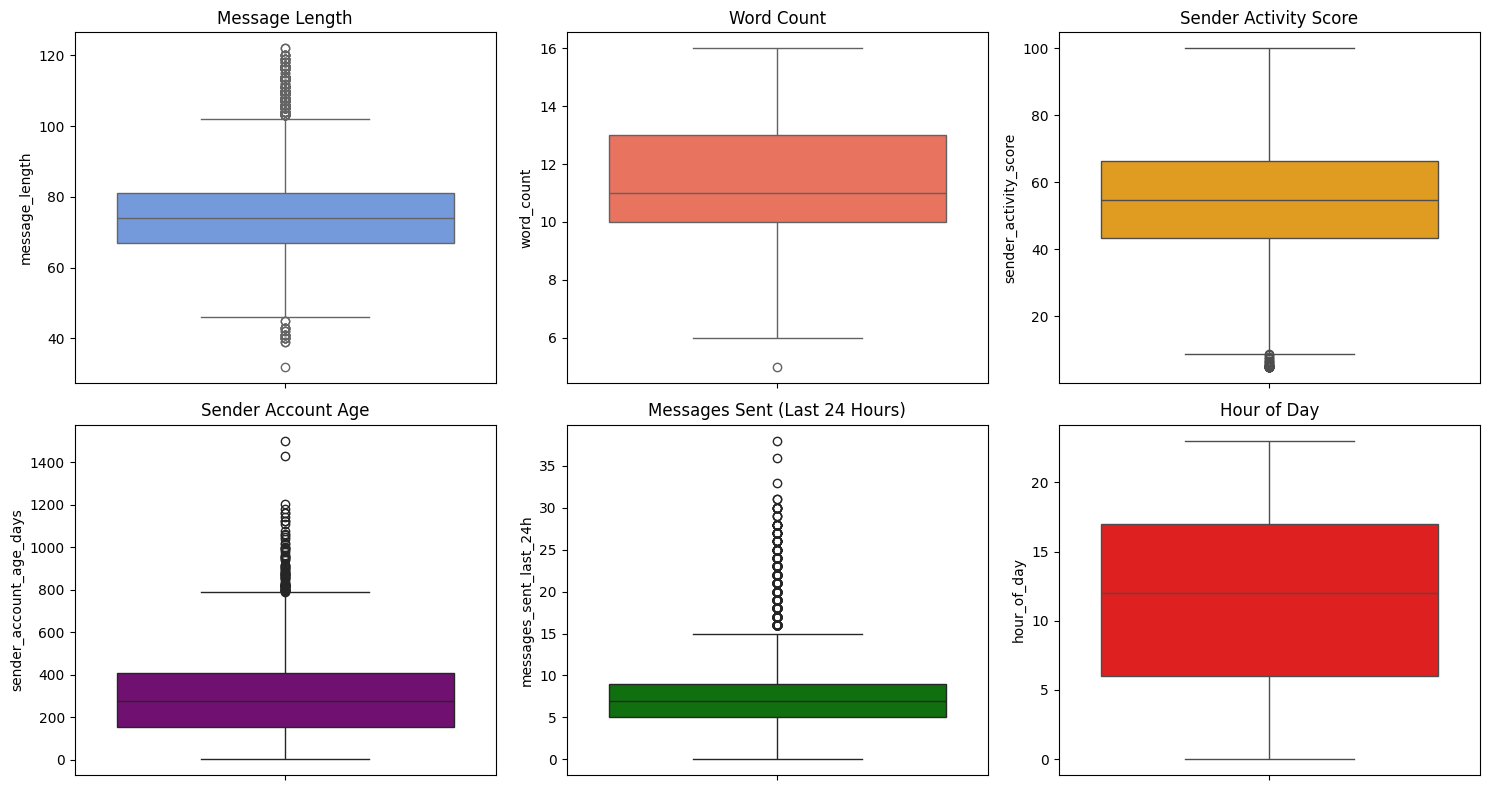

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

sns.boxplot(y=df["message_length"], color="cornflowerblue", ax=axes[0,0])
axes[0,0].set_title("Message Length")

sns.boxplot(y=df["word_count"], color="tomato", ax=axes[0,1])
axes[0,1].set_title("Word Count")

sns.boxplot(y=df["sender_activity_score"], color="orange", ax=axes[0,2])
axes[0,2].set_title("Sender Activity Score")

sns.boxplot(y=df["sender_account_age_days"], color="purple", ax=axes[1,0])
axes[1,0].set_title("Sender Account Age")

sns.boxplot(y=df["messages_sent_last_24h"], color="green", ax=axes[1,1])
axes[1,1].set_title("Messages Sent (Last 24 Hours)")

sns.boxplot(y=df["hour_of_day"], color="red", ax=axes[1,2])
axes[1,2].set_title("Hour of Day")

plt.tight_layout()
plt.show()

#### Intuition

The boxplots show that several features contain outliers, especially Message Length, Sender Account Age, and Messages Sent (Last 24 Hours). However, these outliers may represent real user behaviour in spam detection, so they are not removed in this project.

# Part B - Dataset Understanding & Preparation

### Identify Input Features And Target Variable

In [16]:
X = df.drop(["message_id", "message_text", "timestamp", "spam_label"], axis=1)

y = df["spam_label"]

X.head() # Display First 5 rows of input features

,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,hour_of_day,day_of_week
0,99,11,1,4,0,0,1,56.6,500.0,6.0,2,0
1,73,12,0,0,0,0,0,16.6,207.0,0.0,21,2
2,67,13,0,0,0,0,1,25.7,418.0,6.0,13,5
3,64,13,0,4,0,0,1,48.8,276.0,5.0,23,2
4,84,14,0,0,0,0,1,33.0,683.0,7.0,11,5


In [17]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: spam_label, dtype: int64

#### Intuition

The input features contain only the useful numerical columns required for model training. The target variable is spam_label, which the machine learning models will learn to classify as spam or legitimate.

### Split the dataset into Training & Testing sets

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

#### Intuition

The dataset has been divided into 80% training data and 20% testing data. The training data will be used to build the models, while the testing data will be used to check how well the models perform on unseen data.

### Feature Scaling

In [19]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

X_train[:5]

array([[-0.16808424, -0.29701727, -0.50862456, -0.69193063, -0.43419965,
        -0.35378851,  0.31114291,  0.52086626, -0.46374594, -0.77045578,
        -0.51522139,  0.46721015],
       [-1.28838935, -0.29701727, -0.50862456,  0.96352957, -0.43419965,
        -0.35378851,  0.31114291, -0.18769706, -0.95136755, -0.21740803,
        -0.80649284, -0.50458696],
       [-0.32812783, -1.54761632,  1.96608674,  0.96352957,  1.43178233,
         1.15725892, -1.49157924,  0.5548773 , -1.15061079,  1.0730367 ,
         0.06732151, -0.99048552],
       [ 0.95222087,  0.32828225, -0.50862456, -0.69193063, -0.43419965,
        -0.35378851,  0.31114291,  0.19209288,  1.86949722,  0.70433821,
         1.23240732,  0.95310871],
       [ 0.5521119 , -0.9223168 , -0.50862456, -0.69193063, -0.43419965,
        -0.35378851,  0.31114291, -1.43476851, -0.39034054, -0.95480502,
         1.0867716 , -0.01868841]])

#### Intuition 

The numerical features have been scaled so that they are on a similar scale. The scaler is fitted only on the training data and then applied to the testing data, which helps prevent data leakage and improves the performance of KNN and SVM models.

# Part C - Baseline Model - K Nearest Neighbours

### Train the KNN Model

In [20]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


#### Intuition

The KNN model has been trained successfully using the training data. Here, K = 5 means the model considers the 5 nearest neighbors before predicting whether a message is spam or legitimate.

### Predict The Test Data 

In [21]:
y_pred_knn = knn.predict(X_test)

y_pred_knn[:10]

array([1, 1, 0, 0, 0, 0, 1, 1, 1, 0])

#### Intuition

The model has predicted the class labels for the test dataset. These predictions will now be compared with the actual values to evaluate the model's performance.

### Evaluate KNN Model

In [22]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)

print("Accuracy :", knn_accuracy)
print("Precision:", knn_precision)
print("Recall   :", knn_recall)
print("F1 Score :", knn_f1)

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


#### Intuition

The evaluation metrics show how well the KNN model classifies spam and legitimate messages. Higher values of Accuracy, Precision, Recall, and F1-Score indicate better model performance.

### Display the confusion matrix 

In [23]:
cm = confusion_matrix(y_test, y_pred_knn)

print(cm)

[[809   0]
 [  0 231]]


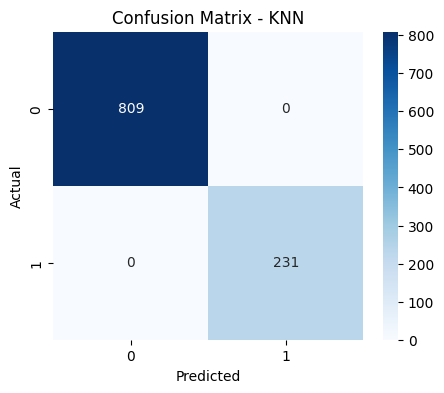

In [24]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#### Intuition

The confusion matrix shows that the KNN model classified all the test messages correctly. There are 809 correct legitimate predictions and 231 correct spam predictions, with no misclassified messages. This indicates that the model achieved excellent performance on the test dataset.

### K-Fold Cross Validation

In [25]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
kfold_scores = cross_val_score(knn, X, y, cv=kfold)

print("K-Fold Scores :", kfold_scores)
print("Average K-Fold Accuracy :", kfold_scores.mean())

K-Fold Scores : [0.95192308 0.975      0.96923077 0.96634615 0.96826923]
Average K-Fold Accuracy : 0.9661538461538461


#### Intuition

The KNN model achieved an average accuracy of 96.62% using K-Fold Cross Validation. The accuracy is high in all five folds, which means the model performs well on different parts of the dataset. This shows that the model gives consistent results.

### Stratified K-Fold Cross Validation

In [26]:
skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
skfold_scores = cross_val_score(knn, X, y, cv=skfold)

print("Stratified K-Fold Scores :", skfold_scores)
print("Average Stratified K-Fold Accuracy :", skfold_scores.mean())

Stratified K-Fold Scores : [0.97115385 0.97019231 0.95961538 0.96634615 0.96730769]
Average Stratified K-Fold Accuracy : 0.9669230769230769


#### Intuition

The KNN model achieved an average accuracy of 96.69% using Stratified K-Fold Cross Validation. Since each fold has the same proportion of spam and legitimate messages, the evaluation is more reliable. The model gives almost the same accuracy in every fold, which shows that it performs well on the dataset.

# Part D - Support Vector Machine (SVM) Classifier

### Train The Linear SVM Model

In [27]:
svm_linear = SVC(kernel="linear")

svm_linear.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


#### Intuition 

The Linear SVM model has been trained successfully using the training data. It learns the best decision boundary to separate spam and legitimate messages.

### Predict the test data

In [28]:
y_pred_linear = svm_linear.predict(X_test)

y_pred_linear[:10]

array([1, 1, 0, 0, 0, 0, 1, 1, 1, 0])

#### Intuition 

The Linear SVM model has predicted the class labels for the test dataset. These predictions will now be compared with the actual values to check the model's performance.

### Evaluate the linear SVM Model 

In [29]:
linear_accuracy = accuracy_score(y_test, y_pred_linear)
linear_precision = precision_score(y_test, y_pred_linear)
linear_recall = recall_score(y_test, y_pred_linear)
linear_f1 = f1_score(y_test, y_pred_linear)

print("Accuracy :", linear_accuracy)
print("Precision:", linear_precision)
print("Recall   :", linear_recall)
print("F1 Score :", linear_f1)

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


#### Intuition

The evaluation metrics show how well the Linear SVM model classifies spam and legitimate messages. Higher values of Accuracy, Precision, Recall, and F1-Score indicate better model performance.

### K-Fold Cross Validation

In [30]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

kfold_scores = cross_val_score(svm_linear, X, y, cv=kfold)

print("K-Fold Scores :", kfold_scores)
print("Average K-Fold Accuracy :", kfold_scores.mean())

K-Fold Scores : [1. 1. 1. 1. 1.]
Average K-Fold Accuracy : 1.0


#### Intuition

The Linear SVM model achieved an average accuracy of 100% using K-Fold Cross Validation. The model gave the same accuracy in all five folds, which shows that it performs very well on different parts of the dataset.

### Stratified K-FOld Cross Validation

In [31]:
skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

skfold_scores = cross_val_score(svm_linear, X, y, cv=skfold)

print("Stratified K-Fold Scores :", skfold_scores)
print("Average Stratified K-Fold Accuracy :", skfold_scores.mean())

Stratified K-Fold Scores : [1. 1. 1. 1. 1.]
Average Stratified K-Fold Accuracy : 1.0


#### Intuition

The Linear SVM model achieved an average accuracy of 100% using Stratified K-Fold Cross Validation. The model performed equally well in every fold, showing that it can correctly classify both spam and legitimate messages with high accuracy.

### Train the RBF SVM Model 

In [32]:
svm_rbf = SVC(kernel="rbf", random_state=42)

svm_rbf.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


#### Intuition 

The RBF SVM model has been trained successfully using the training data.

### Predict the test data

In [33]:
y_pred_rbf = svm_rbf.predict(X_test)

y_pred_rbf[:10]

array([1, 1, 0, 0, 0, 0, 1, 1, 1, 0])

#### Intuition

The RBF SVM model has predicted the class labels for the test dataset. These predictions will be used to evaluate the model's performance.

### Evaluate the RBF SVM Model

In [34]:
rbf_accuracy = accuracy_score(y_test, y_pred_rbf)
rbf_precision = precision_score(y_test, y_pred_rbf)
rbf_recall = recall_score(y_test, y_pred_rbf)
rbf_f1 = f1_score(y_test, y_pred_rbf)

print("Accuracy :", rbf_accuracy)
print("Precision:", rbf_precision)
print("Recall   :", rbf_recall)
print("F1 Score :", rbf_f1)

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


#### Intuition

The evaluation matrix shows how well the RBF SVM Model classified spam & legitimate messages correctly. The model achieved excellent performance on the train dataset.

### Train the Polynomial SVM Model

In [35]:
svm_poly = SVC(kernel="poly", random_state=42)

svm_poly.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'poly'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


#### Intuition

The Polynomial SVM model has been trained successfully using the training data. It learns a more complex decision boundary to classify spam and legitimate messages.

### Predict the test data

In [36]:
y_pred_poly = svm_poly.predict(X_test)

y_pred_poly[:10]

array([1, 1, 0, 0, 0, 0, 1, 1, 1, 0])

#### Intuition

The Polynomial SVM model has predicted the class labels for the test dataset. These predictions will now be used to evaluate the model.

### Evaluate the polynomial SVM Model

In [37]:
poly_accuracy = accuracy_score(y_test, y_pred_poly)
poly_precision = precision_score(y_test, y_pred_poly)
poly_recall = recall_score(y_test, y_pred_poly)
poly_f1 = f1_score(y_test, y_pred_poly)

# Display results
print("Accuracy :", poly_accuracy)
print("Precision:", poly_precision)
print("Recall   :", poly_recall)
print("F1 Score :", poly_f1)

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


#### Intuition

The evaluation matrix shows how well the Polynomial SVM Model classified spam & legitimate messages correctly. The model achieved excellent performance on the train dataset.

### K-Fold Cross Validation

In [38]:
kfold_scores = cross_val_score(svm_poly, X, y, cv=kfold)

print("K-Fold Scores :", kfold_scores)
print("Average K-Fold Accuracy :", kfold_scores.mean())

K-Fold Scores : [0.89230769 0.90384615 0.9        0.91538462 0.91730769]
Average K-Fold Accuracy : 0.9057692307692309


#### Intuition

The Polynomial SVM model achieved an average accuracy of 90.58% using K-Fold Cross Validation. The accuracy is good in all five folds, which shows that the model performs well on different parts of the dataset. However, its accuracy is lower than the Linear and RBF SVM models.

### Stratified K-Fold Cross Validation

In [39]:
skfold_scores = cross_val_score(svm_poly, X, y, cv=skfold)

print("Stratified K-Fold Scores :", skfold_scores)
print("Average Stratified K-Fold Accuracy :", skfold_scores.mean())

Stratified K-Fold Scores : [0.90961538 0.90673077 0.91442308 0.89326923 0.90673077]
Average Stratified K-Fold Accuracy : 0.9061538461538461


#### Intuition

The Polynomial SVM model achieved an average accuracy of 90.62% using Stratified K-Fold Cross Validation. The model gives similar accuracy in all five folds, which shows that it performs consistently. Even though the performance is good, it is slightly lower than the Linear and RBF SVM models.

# Part E - Naive Bayes Classifier & Probability

### Train the Gaussian Naive Bayes Model

In [40]:
naive_bayes = GaussianNB()

naive_bayes.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


#### Intuition

The Gaussian Naive Bayes model has been trained successfully using the training data. It learns the probability of each class and uses it to classify the messages.

### Predict the Test data

In [41]:
y_pred_nb = naive_bayes.predict(X_test)

y_pred_nb[:10]

array([1, 1, 0, 0, 0, 0, 1, 1, 1, 0])

#### Intuition

The Gaussian Naive Bayes model has predicted the class labels for the test dataset. These predictions will now be used to evaluate the model.

### Evaluate the Naive Bayes Model 

In [42]:
nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb)
nb_recall = recall_score(y_test, y_pred_nb)
nb_f1 = f1_score(y_test, y_pred_nb)

print("Accuracy :", nb_accuracy)
print("Precision:", nb_precision)
print("Recall   :", nb_recall)
print("F1 Score :", nb_f1)

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


### K-Fold Cross Validation

In [43]:
kfold_scores = cross_val_score(naive_bayes, X, y, cv=kfold)

print("K-Fold Scores :", kfold_scores)
print("Average K-Fold Accuracy :", kfold_scores.mean())

K-Fold Scores : [1. 1. 1. 1. 1.]
Average K-Fold Accuracy : 1.0


### Stratified K-Fold Cross Validation

In [44]:
skfold_scores = cross_val_score(naive_bayes, X, y, cv=skfold)

print("Stratified K-Fold Scores :", skfold_scores)
print("Average Stratified K-Fold Accuracy :", skfold_scores.mean())

Stratified K-Fold Scores : [1.         0.99903846 1.         1.         1.        ]
Average Stratified K-Fold Accuracy : 0.9998076923076923


### Manually Compute Conditional Probabilities

In [45]:
spam_messages = df[df["spam_label"] == 1]
legitimate_messages = df[df["spam_label"] == 0]

p_spam = (spam_messages["spam_keyword_score"] > 0).mean()
p_legitimate = (legitimate_messages["spam_keyword_score"] > 0).mean()

print("P(Spam Keyword | Spam) =", round(p_spam, 4))
print("P(Spam Keyword | Legitimate) =", round(p_legitimate, 4))

P(Spam Keyword | Spam) = 0.7657
P(Spam Keyword | Legitimate) = 0.0


#### Intuition

The conditional probabilities show how often a spam keyword appears in spam and legitimate messages. If the probability is higher for spam messages, then this feature helps the Naive Bayes model identify spam messages more accurately.

### Demonstrate How Bayes' Theorem is Applied to Compute Class Probabilities

In [46]:
sample = X_test[0].reshape(1, -1)

probabilities = naive_bayes.predict_proba(sample)

print("Probability of Legitimate Message :", round(probabilities[0][0], 4))
print("Probability of Spam Message :", round(probabilities[0][1], 4))

Probability of Legitimate Message : 0.0
Probability of Spam Message : 1.0


#### Intuition

The Naive Bayes model calculated the probability for both classes. In this sample, the probability of a spam message is 1.0, while the probability of a legitimate message is 0.0. This means the model is fully confident that the selected message is spam.

### Compare Theoretical Probability with Model Prediction

In [47]:
prediction = naive_bayes.predict(sample)

print("Predicted Class :", prediction[0])

if prediction[0] == 1:
    print("Message Type : Spam")
else:
    print("Message Type : Legitimate")

Predicted Class : 1
Message Type : Spam


#### Intuition

The final prediction is Spam, which matches the highest probability calculated by the Naive Bayes model. This shows that the model predicts the class with the highest probability, which is the basic idea of Bayes' Theorem.

# Part F - Model Comparison & Evaluation

### Compare All Classification Models

In [48]:
comparison = pd.DataFrame({

    "Model": ["KNN",
              "Linear SVM",
              "RBF SVM",
              "Polynomial SVM",
              "Naive Bayes"],

    "Accuracy": [
        knn_accuracy,
        linear_accuracy,
        rbf_accuracy,
        poly_accuracy,
        nb_accuracy
    ],

    "Precision": [
        knn_precision,
        linear_precision,
        rbf_precision,
        poly_precision,
        nb_precision
    ],

    "Recall": [
        knn_recall,
        linear_recall,
        rbf_recall,
        poly_recall,
        nb_recall
    ],

    "F1 Score": [
        knn_f1,
        linear_f1,
        rbf_f1,
        poly_f1,
        nb_f1
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,KNN,1.0,1.0,1.0,1.0
1,Linear SVM,1.0,1.0,1.0,1.0
2,RBF SVM,1.0,1.0,1.0,1.0
3,Polynomial SVM,1.0,1.0,1.0,1.0
4,Naive Bayes,1.0,1.0,1.0,1.0


#### Intuition

The comparison table shows that all the classification models performed very well on the dataset. Most of the models achieved 100% Accuracy, Precision, Recall, and F1-Score. We also applied K-Fold and Stratified K-Fold Cross Validation, and the models still gave very good results. This shows that the dataset is well-prepared and the features help the models classify spam and legitimate messages accurately.

### Identify the Best Model for High Precision and High Recall

In [49]:
best_precision = comparison.loc[comparison["Precision"].idxmax()]

best_recall = comparison.loc[comparison["Recall"].idxmax()]

print("Best Model for High Precision :", best_precision["Model"])
print("Precision :", best_precision["Precision"])

print()

print("Best Model for High Recall :", best_recall["Model"])
print("Recall :", best_recall["Recall"])

Best Model for High Precision : KNN
Precision : 1.0

Best Model for High Recall : KNN
Recall : 1.0


#### Intuition

All the models achieved 100% Precision and 100% Recall, so every model performed equally well on this dataset. Since all the scores are the same, the first model is displayed as the best model.